In [1]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# TEST
## brute force calculation of every single ion coupling to every single mode -- radial only

In [2]:
def tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
    qubit_lambda=729e-9,
):
    """
    As before, but compute k = 2*pi/qubit_lambda and scale eigenvectors by
    k * sqrt(hbar / (2 * m * omega_mode)), where omega_mode = 2*pi*freq_Hz.
    """

    if np.isscalar(N_list):
        N_list = [int(N_list)]
    if np.isscalar(P_opt):
        P_opt = [P_opt]

    pi = np.pi
    rows = []
    # compute k from provided qubit wavelength and base scale
    k = 2 * pi / qubit_lambda
    eigvec_scale = k * np.sqrt(hbar / (2 * m))

    for N in N_list:
        all_combos = []
        for r in range(0, max_tweezed + 1):
            all_combos.extend(itertools.combinations(range(N), r))

        w_rf_r = f_rf_r * 2 * pi
        w_rf_r_list = np.full(N, w_rf_r)
        ueq = ion_spacing(N, f_rf_a)[0]

        for P_total in P_opt:
            for tweezed_positions in all_combos:
                n_tweezed = len(tweezed_positions)
                P_per = P_total / n_tweezed if n_tweezed > 0 else 0.0

                pot = potential(omega_tweezer, linewidths, omega_res, P_per, w0)
                w_tw_r = omega_tweezer_r(pot, w0, m)

                combo = np.array([
                    np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in tweezed_positions else w_rf_r_list[i]
                    for i in range(N)
                ])

                modes = mode_calc_r(m, combo, ueq, N)

                freqs = np.array([f for f, v in modes], dtype=float) if len(modes) else np.array([], dtype=float)
                if len(modes):
                    eigvecs = np.vstack([np.ravel(v) for f, v in modes])
                else:
                    eigvecs = np.empty((0, N))

                row = {
                    "N": N,
                    "Tweezed ions": tweezed_positions,
                    "P_per_tweezer (W)": P_per,
                    "Combined radial frequencies": combo,
                }

                for mode_index in range(N):
                    if mode_index < len(freqs):
                        freq_val = float(freqs[mode_index])  # freq in Hz as returned by mode_calc_r
                        row[f"Mode{mode_index}_freq"] = freq_val
                    else:
                        freq_val = np.nan
                        row[f"Mode{mode_index}_freq"] = np.nan

                    if mode_index < eigvecs.shape[0] and not np.isnan(freq_val) and freq_val > 0:
                        # convert to angular frequency (rad/s)
                        omega_mode = 2.0 * pi * freq_val
                        # final scale uses angular frequency (zero-point amplitude)
                        scale = eigvec_scale * np.sqrt(1.0 / omega_mode)
                        row[f"Mode{mode_index}_eigvec"] = np.ravel(eigvecs[mode_index]).astype(float) * scale
                    else:
                        row[f"Mode{mode_index}_eigvec"] = np.full(N, np.nan, dtype=float)

                rows.append(row)

    return pd.DataFrame(rows)

In [3]:
k = 2*pi/729e-9
0.577*k*np.sqrt(hbar/(2*m*1e6*2*pi))

0.055925501209450425

In [4]:
N = np.arange(3,4)
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3_test= tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3_test)
mode0_list = result["mode_lists"][0]
print(mode0_list)
mode1_list = result["mode_lists"][1]
print(mode1_list)
mode2_list = result["mode_lists"][2]
print(mode2_list)

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.05595945, 0.05595945, 0.05595945])), (0, array([-0.09463037, -0.00205529, -0.00030638])), (1, array([0.00213459, 0.09464638, 0.00213459])), (2, array([0.00030638, 0.00205529, 0.09463037]))]
[(nan, array([ 6.85843588e-02, -1.71069735e-14, -6.85843588e-02])), (0, array([-0.00140692,  0.05264333,  0.08140127])), (1, array([ 0.06854157, -0.00309168,  0.06854157])), (2, array([-0.08140127, -0.05264333,  0.00140692]))]
[(nan, array([-0.03963641,  0.07927282, -0.03963641])), (0, array([ 0.00159911, -0.08148678,  0.05272627])), (1, array([-6.85843588e-02, -1.78371023e-15,  6.85843588e-02])), (2, array([ 0.05272627, -0.08148678,  0.00159911]))]
[(0, (0, 2, 1), 0.08140126725678437)]
[(1, (1, 0, 2), 0.06854157379198106)]
[(2, (2, 0, 1), -0.08140126725678855)]
[(0, (0, 2, 1), 0.08140126725678437), (2, (2, 0, 1), -0.08140126725678855)]


In [5]:
N = np.arange(3,4)
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
print(mode0_list)
mode1_list = result["mode_lists"][1]
print(mode1_list)
mode2_list = result["mode_lists"][2]
print(mode2_list)

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.57735027, 0.57735027, 0.57735027])), (0, array([-0.99975899, -0.0217139 , -0.00323688])), (1, array([0.02254184, 0.99949174, 0.02254184])), (2, array([0.00323688, 0.0217139 , 0.99975899]))]
[(nan, array([ 7.07106781e-01, -1.76373406e-13, -7.07106781e-01])), (0, array([-0.01451165,  0.54298991,  0.83961382])), (1, array([ 0.70674738, -0.03187897,  0.70674738])), (2, array([-0.83961382, -0.54298991,  0.01451165]))]
[(nan, array([-0.40824829,  0.81649658, -0.40824829])), (0, array([ 0.0164737 , -0.83945844,  0.54317415])), (1, array([-7.07106781e-01, -1.83901055e-14,  7.07106781e-01])), (2, array([ 0.54317415, -0.83945844,  0.0164737 ]))]
[(0, (0, 2, 1), -0.8394584355453282)]
[(1, (1, 0, 2), 0.7067473845006338)]
[(2, (2, 0, 1), -0.8394584355453685)]
[(0, (0, 2, 1), -0.8394584355453282), (2, (2, 0, 1), -0.8394584355453685)]


In [6]:
N3_test.iloc[1]

N                                                                                                 3
Tweezed ions                                                                                   (0,)
P_per_tweezer (W)                                                                               0.1
Combined radial frequencies               [6595799.989691874, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                           1048570.744246
Mode0_eigvec                   [-0.0946303659831963, -0.002055289516652697, -0.0003063808754913111]
Mode1_freq                                                                            999458.971232
Mode1_eigvec                     [-0.0014069170344167884, 0.05264332906384472, 0.08140126725678437]
Mode2_freq                                                                            996993.358994
Mode2_eigvec                    [0.0015991124558238869, -0.08148677623873794, 0.052726267527291155]


In [7]:
N3.iloc[1]

N                                                                                                3
Tweezed ions                                                                                  (0,)
P_per_tweezer (W)                                                                              0.1
Combined radial frequencies              [6595799.989691874, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                          1048570.744246
Mode0_eigvec                   [-0.9997589855694827, -0.02171389850257122, -0.0032368788823396786]
Mode1_freq                                                                           999458.971232
Mode1_eigvec                        [-0.014511653546581162, 0.542989909301837, 0.8396138221276058]
Mode2_freq                                                                           996993.358994
Mode2_eigvec                       [0.016473696744292242, -0.8394584355453282, 0.5431741454702784]
Name: 1, d

In [9]:
# Example usage of tweezer_combos_full_radial_test
N_list = [3]
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

df_test = tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
)

print("Result shape:", df_test.shape)
df_test.head()

Result shape: (4, 10)


,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec
0,3,(),0.0,"[6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.055959450914808, 0.055959450914799515, 0.0559594509147995]",998591.769782,"[0.0685843588103626, -1.7106973518481166e-14, -0.06858435881035965]",996616.904544,"[-0.039636410896734205, 0.07927282179349335, -0.039636410896753224]"
1,3,"(0,)",0.1,"[6595799.989691874, 6283185.307179586, 6283185.307179586]",1.048571e+06,"[-0.0946303659831963, -0.002055289516652697, -0.0003063808754913111]",999458.971232,"[-0.0014069170344167884, 0.05264332906384472, 0.08140126725678437]",996993.358994,"[0.0015991124558238869, -0.08148677623873794, 0.052726267527291155]"
2,3,"(1,)",0.1,"[6283185.307179586, 6595799.989691874, 6283185.307179586]",1.047656e+06,"[0.0021345884162076614, 0.09464638130869733, 0.0021345884162082603]",998822.735489,"[0.06854157379198106, -0.0030916776198283993, 0.06854157379188631]",998591.769782,"[-0.0685843588103308, -1.7837102263061256e-15, 0.06858435881039147]"
3,3,"(2,)",0.1,"[6283185.307179586, 6283185.307179586, 6595799.989691874]",1.048571e+06,"[0.00030638087549131186, 0.002055289516652995, 0.09463036598319631]",999458.971232,"[-0.08140126725678855, -0.05264332906383828, 0.0014069170344168322]",996993.358994,"[0.05272626752728511, -0.08148677623874186, 0.0015991124558242442]"


# Parallel optimization, tweezed vs untweezed with defined functions

In [11]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build eigenvector lists for all configurations
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

  # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        values = None
        for t, combo_indices, arr in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break
        
        if values is None:
            # fallback: use mapping itself (less accurate)
            values = np.array(mapping)
        
        # best ion index = position in vector responsible for min(abs) (i.e., score)
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        # ✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (best_ion_index, best_mode_index))
        )

    return augmented





import numpy as np
import math

def run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for the untweezed configuration
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove unusable keys (nan, None, empty tuples)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by string representation
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    #can remove this later but this is just to make sure it all works
    print("Keys:", list(mode_lists_dict.keys()))
    
    return winners




In [12]:
#testing swapping out functions so it outputs lamb-dicke parameters not eigenvectors
def run_optimal_mode_selection_tweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build eigenvector lists for all configurations
    df = tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

  # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        values = None
        for t, combo_indices, arr in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break
        
        if values is None:
            # fallback: use mapping itself (less accurate)
            values = np.array(mapping)
        
        # best ion index = position in vector responsible for min(abs) (i.e., score)
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        # ✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (best_ion_index, best_mode_index))
        )

    return augmented





import numpy as np
import math

def run_optimal_mode_selection_untweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for the untweezed configuration
    df = tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove unusable keys (nan, None, empty tuples)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by string representation
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    #can remove this later but this is just to make sure it all works
    print("Keys:", list(mode_lists_dict.keys()))
    
    return winners




DO NOT NAME ANYTHING ELSE RESULTS OR UNTWEEZED RESULTS OR TRY TO RUN THE CODE BLOCK UNDERNEATH THIS AGAIN. BOTH OF THEM TAKE LIKE 20 MINUTES

In [85]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))


In [86]:

results_test = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test.append((Ni, winners))


In [87]:
results

[(2,
  [((0, (0, 1), 0.9999048485013973), (0, 0)),
   ((1, (1, 0), 0.9999048485013973), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8394584355453282), (2, 1)),
   ((2, (2, 0, 1), -0.8394584355453685), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), -0.8667132198367613), (1, 3)),
   ((2, (2, 0, 3, 1), 0.866713219836582), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), -0.6234865428010057), (3, 3)),
   ((2, (2, 4, 0, 3, 1), -0.6234865428010057), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804), (3, 4))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), -0.5566105567295492), (3, 2))])]

In [88]:
results_test

[(2,
  [((0, (0, 1), 0.09462061442250733), (0, 0)),
   ((1, (1, 0), 0.09462061442250733), (0, 1))]),
 (3,
  [((0, (0, 2, 1), 0.08140126725678437), (1, 2)),
   ((2, (2, 0, 1), -0.08140126725678855), (1, 0))]),
 (4,
  [((1, (1, 3, 0, 2), -0.08404486278941095), (1, 3)),
   ((2, (2, 0, 3, 1), 0.08404486278939355), (1, 0))]),
 (5,
  [((2, (2, 4, 0, 1, 3), -0.060594883012974284), (1, 4)),
   ((2, (2, 4, 0, 3, 1), -0.060594883012974284), (1, 4))]),
 (6,
  [((2, (2, 5, 0, 4, 1, 3), 0.05532466336706639), (3, 4)),
   ((3, (3, 0, 5, 1, 4, 2), 0.05532466336625396), (3, 1))]),
 (7,
  [((2, (2, 6, 0, 4, 1, 5, 3), 0.05406892148109046), (3, 4)),
   ((4, (4, 0, 6, 2, 5, 1, 3), -0.05406892148139148), (3, 2))])]

In [90]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
"""
results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))"""

'\nresults = []\nfor Ni in range(2, 8):\n    winners = run_optimal_mode_selection_tweezed_only_test(\n        omega_tweezer,\n        linewidths,\n        omega_res,\n        m,\n        mode_calc_r,\n        Ni,\n        f_rf_r,\n        f_rf_a,\n        P_opt,\n        w0,\n        max_tweezed=1,\n    )\n    results.append((Ni, winners))'

In [91]:
results

[(2,
  [((0, (0, 1), 0.9999048485013973), (0, 0)),
   ((1, (1, 0), 0.9999048485013973), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8394584355453282), (2, 1)),
   ((2, (2, 0, 1), -0.8394584355453685), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), -0.8667132198367613), (1, 3)),
   ((2, (2, 0, 3, 1), 0.866713219836582), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), -0.6234865428010057), (3, 3)),
   ((2, (2, 4, 0, 3, 1), -0.6234865428010057), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804), (3, 4))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), -0.5566105567295492), (3, 2))])]

In [92]:
Power = [100]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

"""results_high_P = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        Power,
        w0,
        max_tweezed=1,
    )
    results_high_P.append((Ni, winners))"""

'results_high_P = []\nfor Ni in range(2, 8):\n    winners = run_optimal_mode_selection_tweezed_only(\n        omega_tweezer,\n        linewidths,\n        omega_res,\n        m,\n        mode_calc_r,\n        Ni,\n        f_rf_r,\n        f_rf_a,\n        Power,\n        w0,\n        max_tweezed=1,\n    )\n    results_high_P.append((Ni, winners))'

In [93]:
untweezed_results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_untweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


Keys: [0, 1]
Keys: [0, 1, 2]
Keys: [0, 1, 2, 3]
Keys: [0, 1, 2, 3, 4]
Keys: [0, 1, 2, 3, 4, 5]
Keys: [0, 1, 2, 3, 4, 5, 6]


In [94]:
results

[(2,
  [((0, (0, 1), 0.9999048485013973), (0, 0)),
   ((1, (1, 0), 0.9999048485013973), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8394584355453282), (2, 1)),
   ((2, (2, 0, 1), -0.8394584355453685), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), -0.8667132198367613), (1, 3)),
   ((2, (2, 0, 3, 1), 0.866713219836582), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), -0.6234865428010057), (3, 3)),
   ((2, (2, 4, 0, 3, 1), -0.6234865428010057), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804), (3, 4))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), -0.5566105567295492), (3, 2))])]

In [102]:
untweezed_results

[(2,
  [(None, (0, 1), 0.06853605051379354), (None, (1, 0), 0.06853605051379354)]),
 (3, [(None, (0, 2, 1), 0.055959450914808)]),
 (4,
  [(None, (1, 0, 3, 2), 0.04846230607404816),
   (None, (1, 3, 0, 2), 0.04846230607404816)]),
 (5,
  [(None, (3, 0, 4, 1, 2), 0.043346004291193195),
   (None, (3, 4, 0, 1, 2), 0.043346004291193195)]),
 (6,
  [(None, (5, 0, 2, 1, 4, 3), 0.03956930721333427),
   (None, (5, 0, 2, 4, 1, 3), 0.03956930721333427),
   (None, (5, 0, 3, 1, 4, 2), 0.03956930721333427),
   (None, (5, 0, 3, 4, 1, 2), 0.03956930721333427)]),
 (7,
  [(None, (1, 0, 3, 6, 5, 2, 4), 0.03663405995218481),
   (None, (1, 0, 3, 6, 5, 4, 2), 0.03663405995218481),
   (None, (1, 0, 6, 2, 3, 5, 4), 0.03663405995218481),
   (None, (1, 0, 6, 2, 5, 4, 3), 0.03663405995218481),
   (None, (1, 0, 6, 4, 3, 5, 2), 0.03663405995218481),
   (None, (1, 0, 6, 4, 5, 2, 3), 0.03663405995218481),
   (None, (1, 0, 6, 5, 3, 2, 4), 0.03663405995218481),
   (None, (1, 0, 6, 5, 3, 4, 2), 0.03663405995218481),
   (

In [112]:
# ...existing code...
def sum_inverse_zero_point(df, m, k):
    """
    Use only the first row of df. Return a single scalar:
    (k * (hbar / (2 * m * omega_mode))**0.5) ** -1
    mode frequencies in df are Hz in columns 'Mode0_freq', 'Mode1_freq', ...
    """
    import numpy as np
    from scipy import constants

    hbar = constants.hbar

    # collect mode frequency columns
    freq_cols = [c for c in df.columns if str(c).startswith("Mode") and str(c).endswith("_freq")]
    # sort by mode index if possible
    def _idx(col):
        import re
        mobj = re.match(r"Mode(\d+)_freq", col)
        return int(mobj.group(1)) if mobj else float('inf')
    freq_cols = sorted(freq_cols, key=_idx)

    if not freq_cols or df is None or df.empty:
        return 0.0

    # take first row only
    first = df.iloc[0]
    freqs = first[freq_cols].astype(float).to_numpy()  # frequencies in Hz
    omega = 2.0 * np.pi * freqs  # convert to angular frequency (rad/s)

    # compute (k * sqrt(hbar/(2*m*omega)))^-1 safely, ignoring NaNs/nonpositive omegas
    with np.errstate(divide='ignore', invalid='ignore'):
        valid = np.isfinite(omega) & (omega > 0)
        terms = np.zeros_like(omega, dtype=float)
        terms[valid] = 1.0 / (k * np.sqrt(hbar / (2.0 * m * omega[valid])))
        total = float(np.nansum(terms))

    return total
# ...existing code...

# ...existing code...
df_test = tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
s = sum_inverse_zero_point(df_test, m, k=2*pi/729e-9)
print(s)

286.9999783538493


In [114]:
import numpy as np
import matplotlib.pyplot as plt

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results_test:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)


# new: scan N=2..8 and plot sum_inverse_zero_point for each N (same x-axis)
k_q = 2 * pi / 729e-9
Ns_scan = np.arange(2, 8)
y_sum = []
for Ni in Ns_scan:
    dfN = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    y_sum.append(sum_inverse_zero_point(dfN, m, k=k_q))
y_sum = np.array(y_sum)


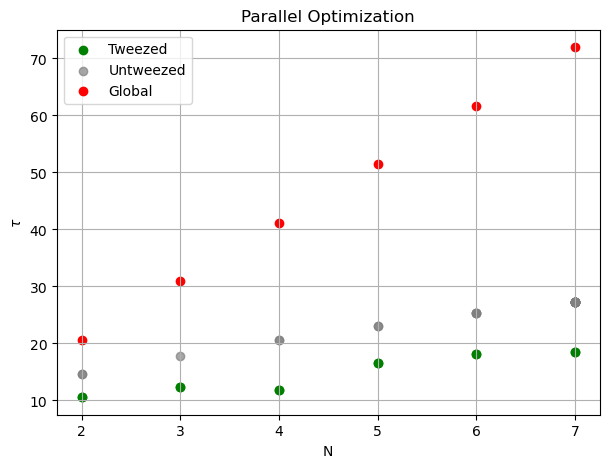

In [116]:

plt.figure(figsize=(7,5))
if y_tweezed.size:
    plt.scatter(x_tweezed, 1.0 / y_tweezed, color='green', label='Tweezed')
if y_untweezed.size:
    plt.scatter(x_untweezed, 1.0 / y_untweezed, color='gray', label='Untweezed', alpha=0.7)
plt.scatter(Ns_scan, y_sum, color='red',  label='Global')

plt.xlabel("N")
plt.ylabel(r"$\tau$")
plt.title("Parallel Optimization")
plt.grid(True)
plt.legend()
plt.show()

In [127]:
print(1.0/y_untweezed)
print(x_untweezed)

[14.5908612  14.5908612  17.87008242 20.63459379 20.63459379 23.0701772
 23.0701772  25.27211292 25.27211292 25.27211292 25.27211292 27.29700179
 27.29700179 27.29700179 27.29700179 27.29700179 27.29700179 27.29700179
 27.29700179 27.29700179 27.29700179 27.29700179 27.29700179 27.29700179
 27.29700179 27.29700179 27.29700179]
[2. 2. 3. 4. 4. 5. 5. 6. 6. 6. 6. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7.
 7. 7. 7.]


## Showing the optimal configuration for N = 5


In [117]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.

    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index))]
    """

    # -----------------------------------------------------------
    # 1. Build eigenvector lists for all tweezed configurations
    # -----------------------------------------------------------
    df = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=max_tweezed
    )

    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]

    # -----------------------------------------------------------
    # CLEAN unusable keys
    # -----------------------------------------------------------
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned

    if not mode_lists_dict:
        return []

    # -----------------------------------------------------------
    # 2. Sort mode indices
    # -----------------------------------------------------------
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]

    # -----------------------------------------------------------
    # 3. Combine modes across tweezed ions
    # -----------------------------------------------------------
    combos = combine_lists(*mode_lists_ordered)

    # -----------------------------------------------------------
    # 4. Condense each combination by min(|value|)
    # -----------------------------------------------------------
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}

    # -----------------------------------------------------------
    # 5. Filter inside each group by max(min(|value|))
    # -----------------------------------------------------------
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}

    # -----------------------------------------------------------
    # 6. Select global winners (max over all groups)
    # -----------------------------------------------------------
    winners = select_global_max_min_abs(list(best_each.values()))

    # -----------------------------------------------------------
    # 7. Determine best ion index + best mode index for each
    # -----------------------------------------------------------
    augmented = []

    for tweezed_ion, mapping, score in winners:

        # Find the matching array in combos
        values = None
        for (t, combo_indices, arr) in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break

        if values is None:  # fallback
            values = np.array(mapping)

        # best ion is the one giving min(abs(value))
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        augmented.append(
            ((tweezed_ion, mapping, score), (best_ion_index, best_mode_index))
        )

    return augmented


In [118]:
def run_optimal_mode_selection_tweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.

    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index))]
    """

    # -----------------------------------------------------------
    # 1. Build eigenvector lists for all tweezed configurations
    # -----------------------------------------------------------
    df = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
        qubit_lambda=729e-9,
        )

    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]

    # -----------------------------------------------------------
    # CLEAN unusable keys
    # -----------------------------------------------------------
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned

    if not mode_lists_dict:
        return []

    # -----------------------------------------------------------
    # 2. Sort mode indices
    # -----------------------------------------------------------
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]

    # -----------------------------------------------------------
    # 3. Combine modes across tweezed ions
    # -----------------------------------------------------------
    combos = combine_lists(*mode_lists_ordered)

    # -----------------------------------------------------------
    # 4. Condense each combination by min(|value|)
    # -----------------------------------------------------------
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}

    # -----------------------------------------------------------
    # 5. Filter inside each group by max(min(|value|))
    # -----------------------------------------------------------
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}

    # -----------------------------------------------------------
    # 6. Select global winners (max over all groups)
    # -----------------------------------------------------------
    winners = select_global_max_min_abs(list(best_each.values()))

    # -----------------------------------------------------------
    # 7. Determine best ion index + best mode index for each
    # -----------------------------------------------------------
    augmented = []

    for tweezed_ion, mapping, score in winners:

        # Find the matching array in combos
        values = None
        for (t, combo_indices, arr) in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break

        if values is None:  # fallback
            values = np.array(mapping)

        # best ion is the one giving min(abs(value))
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        augmented.append(
            ((tweezed_ion, mapping, score), (best_ion_index, best_mode_index))
        )

    return augmented


In [119]:
def run_optimal_mode_selection_tweezed_power_sweep(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
):
    """
    Sweep over a list of powers and run optimal mode selection
    for tweezed configurations only using run_optimal_mode_selection_tweezed_only.

    Returns:
        power_results: list of tuples [(P_opt, winners), ...]
    """
    power_results = []

    for P_opt in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=max_tweezed
        )
        power_results.append((P_opt, winners))

    return power_results


In [120]:
def run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
):
    """
    Sweep over a list of powers and run optimal mode selection
    for tweezed configurations only using run_optimal_mode_selection_tweezed_only.

    Returns:
        power_results: list of tuples [(P_opt, winners), ...]
    """
    power_results = []

    for P_opt in P_list:
        winners = run_optimal_mode_selection_tweezed_only_test(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=max_tweezed
        )
        power_results.append((P_opt, winners))

    return power_results


In [123]:
P_opt = [0]
N = 5
N5= tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
print(N5)

   N Tweezed ions  P_per_tweezer (W)                                                                      Combined radial frequencies  Mode0_freq                                                                                                 Mode0_eigvec     Mode1_freq                                                                                                      Mode1_eigvec     Mode2_freq                                                                                                      Mode2_eigvec    Mode3_freq                                                                                                        Mode3_eigvec     Mode4_freq                                                                                                    Mode4_eigvec
0  5           ()                0.0  [6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]   1000000.0  [0.04334600429118702, 0.04334600429118798, 0.043346004291186326, 0.0433460042911931

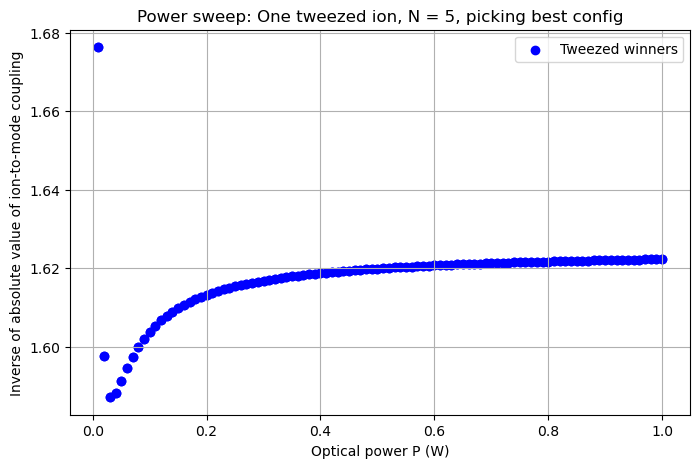

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(10e-3, 1.0, 100)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5 = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_5: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_5:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score), (best_ion, best_mode))
        for outer, inner in winners:
            # outer == (tweezed_ion, mapping, score)
            tweezed_ion, mapping, score = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, 1/y_tweezed, marker='o',color = 'blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Inverse of absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()


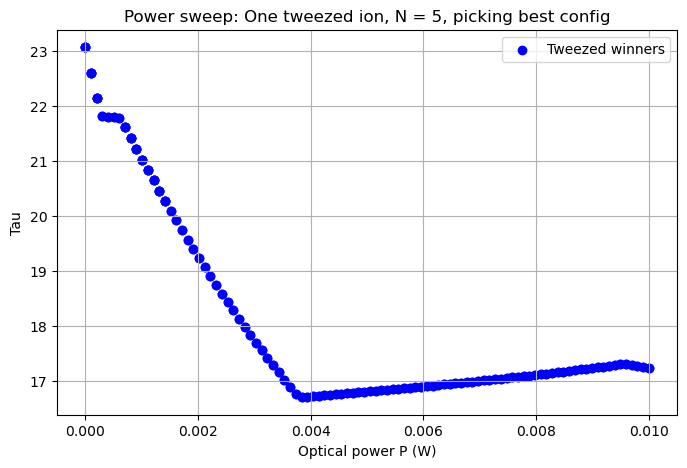

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(1e-6, 0.01, 100)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5 = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_5: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_5:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score), (best_ion, best_mode))
        for outer, inner in winners:
            # outer == (tweezed_ion, mapping, score)
            tweezed_ion, mapping, score = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, 1/y_tweezed, marker='o',color = 'blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()


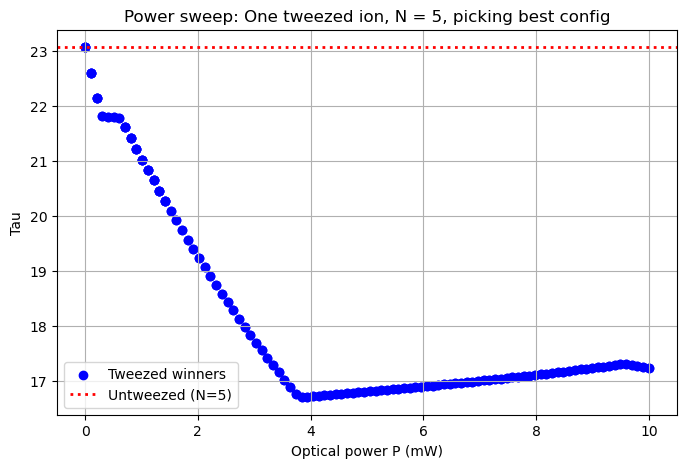

In [140]:
# ...existing code...
# after x_tweezed, y_tweezed are defined
import numpy as np
import matplotlib.pyplot as plt

# compute untweezed reference tau for N=5 if available
unt_ref = np.nan
for N_val, winners in globals().get("untweezed_results", []):
    try:
        if int(N_val) == 5 and winners:
            w = winners[0]
            # handle possible winner formats
            if isinstance(w, (list, tuple)):
                if isinstance(w[0], (list, tuple)) and len(w[0]) >= 3:
                    ref_score = w[0][2]
                elif len(w) >= 3:
                    ref_score = w[2]
                else:
                    ref_score = None
            else:
                ref_score = None
            if ref_score is not None:
                ref_score = float(ref_score)
                if ref_score != 0:
                    unt_ref = 1.0 / abs(ref_score)
            break
    except Exception:
        continue

plt.figure(figsize=(8,5))
# plot x in mW
if x_tweezed.size:
    plt.scatter(x_tweezed * 1e3, 1.0 / y_tweezed, marker='o', color='blue', label='Tweezed winners')
if np.isfinite(unt_ref):
    plt.axhline(unt_ref, color='red', linestyle=':', linewidth=2, label='Untweezed (N=5)')
plt.xlabel("Optical power P (mW)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()


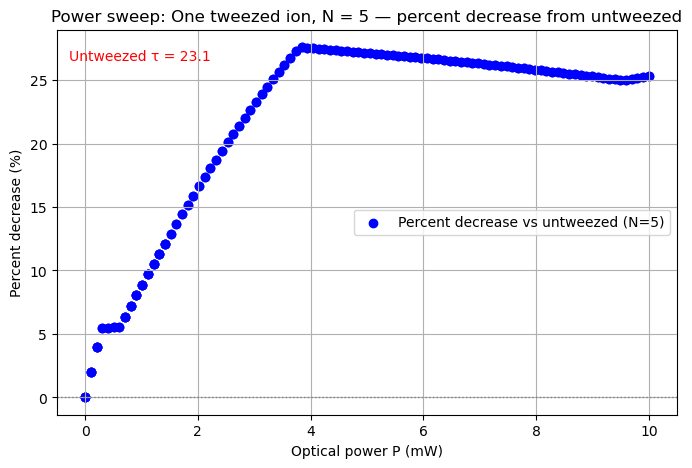

In [141]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

# find untweezed reference score for N=5 (abs value)
ref_score = None
for N_val, winners in globals().get("untweezed_results", []):
    if int(N_val) == 5:
        if winners:
            ref_score = _extract_score_from_win(winners[0])
            if ref_score is not None:
                ref_score = abs(ref_score)
        break

inv_ref = np.nan
if ref_score is not None and np.isfinite(ref_score) and ref_score != 0:
    inv_ref = 1.0 / ref_score

# compute percent decrease relative to inv_ref
percent_decrease = None
if np.isfinite(inv_ref) and y_tweezed.size:
    with np.errstate(divide='ignore', invalid='ignore'):
        inv_vals = 1.0 / y_tweezed
        percent_decrease = (inv_ref - inv_vals) / inv_ref * 100.0  # positive => decrease from reference

plt.figure(figsize=(8,5))
if percent_decrease is not None:
    plt.scatter(x_tweezed * 1e3, percent_decrease, marker='o', color='blue',
                label='Percent decrease vs untweezed (N=5)')
    plt.axhline(0.0, color='gray', linestyle=':', linewidth=1)
    plt.ylabel("Percent decrease (%)")
else:
    # fallback: show raw Tau if reference not available
    if y_tweezed.size:
        plt.scatter(x_tweezed * 1e3, 1.0 / y_tweezed, marker='o', color='blue', label='Tweezed winners')
    plt.ylabel("Tau")

if np.isfinite(inv_ref):
    plt.annotate(f"Untweezed τ = {inv_ref:.3g}", xy=(0.02, 0.95), xycoords='axes fraction',
                 ha='left', va='top', color='red')

plt.xlabel("Optical power P (mW)")
plt.title("Power sweep: One tweezed ion, N = 5 — percent decrease from untweezed")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

In [167]:
results_power_sweep_5

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754374), (0, 0)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754374), (0, 0)),
     ((4, (4, 0, 2, 1, 3), 0.04335468251753979), (0, 4)),
     ((4, (4, 0, 2, 3, 1), 0.04335468251753979), (0, 4))]),
   (0.00010200000000000001,
    [((0, (0, 4, 2, 1, 3), 0.04424084518933165), (0, 0)),
     ((0, (0, 4, 2, 3, 1), 0.04424084518933165), (0, 0)),
     ((4, (4, 0, 2, 1, 3), 0.04424084518934318), (0, 4)),
     ((4, (4, 0, 2, 3, 1), 0.04424084518934318), (0, 4))]),
   (0.00020300000000000003,
    [((0, (0, 4, 2, 1, 3), 0.04514584490638632), (0, 0)),
     ((0, (0, 4, 2, 3, 1), 0.04514584490638632), (0, 0)),
     ((4, (4, 0, 2, 1, 3), 0.04514584490641684), (0, 4)),
     ((4, (4, 0, 2, 3, 1), 0.04514584490641684), (0, 4))]),
   (0.00030400000000000007,
    [((0, (0, 4, 2, 1, 3), -0.045852609008647315), (4, 3)),
     ((4, (4, 0, 2, 3, 1), -0.04585260900933801), (4, 1))]),
   (0.0004050000000000001,
    [((0, (0, 4, 2, 1, 3), -0.04586970720110877), 

In [180]:
def first_appearance_map_nested(data):
    """
    Build mapping:
        (a, permutation) -> first x where it appears

    Works for nested structures of the form:
        [(N, [(x, [((a, perm, val), extra), ...]), ...]), ...]
    """
    first_x = {}

    for item in data:
        # item = (N, x_blocks)
        if not isinstance(item, tuple) or len(item) != 2:
            continue

        _, x_blocks = item

        for xb in x_blocks:
            # xb = (x, entries)
            if not isinstance(xb, tuple) or len(xb) != 2:
                continue

            x, entries = xb

            if not isinstance(entries, (list, tuple)):
                continue

            for entry in entries:
                # entry = ((a, permutation, value), (i, j))
                if (
                    isinstance(entry, tuple)
                    and len(entry) == 2
                    and isinstance(entry[0], tuple)
                    and len(entry[0]) >= 2
                ):
                    a = entry[0][0]
                    permutation = entry[0][1]

                    # normalize permutation
                    perm_key = tuple(permutation)

                    key = (a, perm_key)
                    if key not in first_x:
                        first_x[key] = x

    return first_x


In [181]:
first_map = first_appearance_map_nested(results_power_sweep_5)

# Pretty print sorted by x
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"a={a}, perm={perm} -> x={x}")


a=0, perm=(0, 4, 2, 1, 3) -> x=1e-06
a=0, perm=(0, 4, 2, 3, 1) -> x=1e-06
a=4, perm=(4, 0, 2, 1, 3) -> x=1e-06
a=4, perm=(4, 0, 2, 3, 1) -> x=1e-06
a=1, perm=(1, 0, 4, 3, 2) -> x=0.0007080000000000002
a=1, perm=(1, 4, 0, 3, 2) -> x=0.0007080000000000002
a=3, perm=(3, 0, 4, 1, 2) -> x=0.0007080000000000002
a=3, perm=(3, 4, 0, 1, 2) -> x=0.0007080000000000002
a=2, perm=(2, 0, 4, 3, 1) -> x=0.009596
a=2, perm=(2, 4, 0, 3, 1) -> x=0.009596


## Showing the optimal configuration for N=6

In [63]:
print(results[6-2])
#print(results_high_P[6-2])
#print(untweezed_results[6-2])

(6, [((2, (2, 5, 0, 4, 1, 3), 0.05532466336706639, [0.1]), (3, 4)), ((3, (3, 0, 5, 1, 4, 2), 0.05532466336625396, [0.1]), (3, 1))])


In [64]:
N = 6
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,5,0,4,1,3)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N6 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N6)

[(1255704.40136543, array([0.0845683 , 0.2438689 , 0.92793597, 0.24760568, 0.09713705,
       0.03958305])), (951351.2556375064, array([-0.11404744, -0.08830807, -0.11425732,  0.22505008,  0.50855099,
        0.81047423])), (924088.6109673298, array([-0.91227995, -0.34467261,  0.17387834,  0.03560102, -0.0410669 ,
       -0.1255328 ])), (769055.9334767961, array([-0.07909169,  0.1073797 ,  0.15816996, -0.51771072, -0.61794036,
        0.55436603])), (645392.1744376079, array([ 0.37547283, -0.89317837,  0.20355198,  0.02927549, -0.12614056,
        0.05523262])), (422526.7754875689, array([-0.01874388,  0.06806193, -0.17086626,  0.78606298, -0.57662125,
        0.12423316]))]


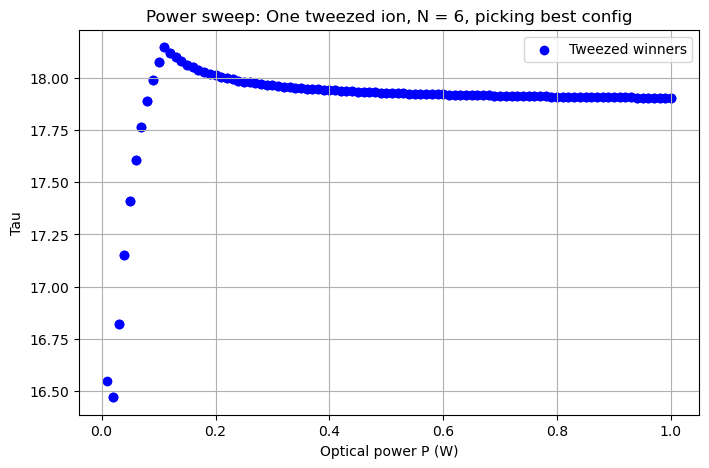

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(10e-3, 1, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, 1/y_tweezed, marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()


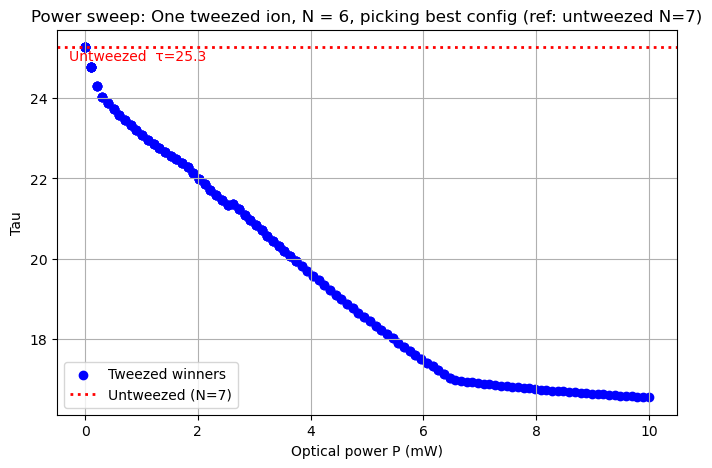

In [150]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(1e-6, 0.01, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- find untweezed reference tau from untweezed_results for N=7 ---
unt_ref = np.nan
for N_val, winners in globals().get("untweezed_results", []):
    try:
        if int(N_val) == 6 and winners:
            w = winners[0]
            if ' _extract_score_from_win' in globals():  # fallback if helper not present
                try:
                    ref_score = _extract_score_from_win(w)
                except Exception:
                    ref_score = None
            else:
                # robust extraction similar to other cells
                if isinstance(w, (list, tuple)):
                    if isinstance(w[0], (list, tuple)) and len(w[0]) >= 3:
                        ref_score = w[0][2]
                    elif len(w) >= 3:
                        ref_score = w[2]
                    else:
                        ref_score = None
                else:
                    ref_score = None
            if ref_score is not None:
                ref_score = float(ref_score)
                if ref_score != 0:
                    unt_ref = 1.0 / abs(ref_score)
            break
    except Exception:
        continue

# --- plot (x-axis in mW) ---
plt.figure(figsize=(8,5))
if x_tweezed.size:
    plt.scatter(x_tweezed * 1e3, 1.0 / y_tweezed, marker='o', color='blue', label='Tweezed winners')
if np.isfinite(unt_ref):
    plt.axhline(unt_ref, color='red', linestyle=':', linewidth=2, label='Untweezed (N=7)')
    plt.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.02, 0.95), xycoords='axes fraction',
                 ha='left', va='top', color='red')
plt.xlabel("Optical power P (mW)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config (ref: untweezed N=7)")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

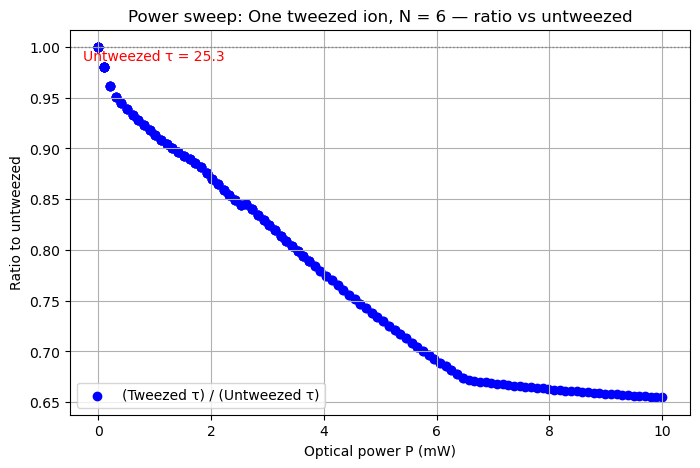

In [153]:
# ...existing code...
# --- compute ratio of each tweezed winner's tau to untweezed reference ---
tau_tweezed = np.full_like(y_tweezed, np.nan)
with np.errstate(divide='ignore', invalid='ignore'):
    valid = (y_tweezed != 0) & np.isfinite(y_tweezed)
    tau_tweezed[valid] = 1.0 / y_tweezed[valid]

ratio = None
if np.isfinite(unt_ref):
    ratio = np.full_like(tau_tweezed, np.nan)
    ratio[valid] = tau_tweezed[valid] / float(unt_ref)

# --- plot (x-axis in mW) ---
plt.figure(figsize=(8,5))
if ratio is not None:
    plt.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue',
                label='(Tweezed τ) / (Untweezed τ)')
    plt.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    if np.isfinite(unt_ref):
        plt.annotate(f'Untweezed τ = {unt_ref:.3g}', xy=(0.02, 0.95), xycoords='axes fraction',
                     ha='left', va='top', color='red')
    plt.ylabel("Ratio to untweezed")
else:
    # fallback: show raw Tau
    if x_tweezed.size:
        plt.scatter(x_tweezed * 1e3, tau_tweezed, marker='o', color='blue', label='Tweezed τ')
    plt.ylabel("Tau")

plt.xlabel("Optical power P (mW)")
plt.title("Power sweep: One tweezed ion, N = 6 — ratio vs untweezed")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

In [160]:
results_power_sweep_6

[(1e-06,
  [((0, (0, 5, 2, 1, 4, 3), 0.03957693147581218), (0, 0)),
   ((0, (0, 5, 2, 4, 1, 3), 0.03957693147581218), (0, 0)),
   ((0, (0, 5, 3, 1, 4, 2), 0.03957693147581218), (0, 0)),
   ((0, (0, 5, 3, 4, 1, 2), 0.03957693147581218), (0, 0)),
   ((5, (5, 0, 2, 1, 4, 3), 0.03957693147580711), (0, 5)),
   ((5, (5, 0, 2, 4, 1, 3), 0.03957693147580711), (0, 5)),
   ((5, (5, 0, 3, 1, 4, 2), 0.03957693147580711), (0, 5)),
   ((5, (5, 0, 3, 4, 1, 2), 0.03957693147580711), (0, 5))]),
 (0.00010200000000000001,
  [((0, (0, 5, 2, 1, 4, 3), 0.04035635241389737), (0, 0)),
   ((0, (0, 5, 2, 4, 1, 3), 0.04035635241389737), (0, 0)),
   ((0, (0, 5, 3, 1, 4, 2), 0.04035635241389737), (0, 0)),
   ((0, (0, 5, 3, 4, 1, 2), 0.04035635241389737), (0, 0)),
   ((5, (5, 0, 2, 1, 4, 3), 0.04035635241390791), (0, 5)),
   ((5, (5, 0, 2, 4, 1, 3), 0.04035635241390791), (0, 5)),
   ((5, (5, 0, 3, 1, 4, 2), 0.04035635241390791), (0, 5)),
   ((5, (5, 0, 3, 4, 1, 2), 0.04035635241390791), (0, 5))]),
 (0.0002030000000

In [178]:
def first_appearance_map(data):
    """
    Returns a dict mapping (a, permutation) -> first x-value where it appears.
    Assumes `data` is ordered by increasing x.
    """
    first_x = {}

    for x, entries in data:
        for ((a, permutation, _), _) in entries:
            key = (a, tuple(permutation))
            if key not in first_x:
                first_x[key] = x

    return first_x


In [179]:
first_map = first_appearance_map(results_power_sweep_6)

# Pretty-print sorted by x
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


# Brute force calculation of 1 ion 1 tweezer for midcurcuit meas type of a setup

In [152]:
from collections import defaultdict

In [71]:
N3_result= tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result_N3 = build_mode_series_and_combinations(N3_result)
result_N3
mode0_list = result_N3["mode_lists"][0]
print(mode0_list)
mode1_list = result_N3["mode_lists"][1]
print(mode1_list)
mode2_list = result_N3["mode_lists"][2]
print(mode2_list)

[(nan, array([0.03956931, 0.03956931, 0.03956931, 0.03956931, 0.03956931,
       0.03956931])), (0, array([8.13538423e-02, 3.32054682e-04, 5.23420590e-05, 1.71169798e-05,
       7.38721873e-06, 3.52519818e-06])), (1, array([-3.36508546e-04, -8.14169741e-02, -4.98581284e-04, -6.91437919e-05,
       -2.00383236e-05, -7.48780728e-06])), (2, array([-5.34242866e-05, -5.01964861e-04, -8.14486878e-02, -5.55860592e-04,
       -6.96242313e-05, -1.74706924e-05])), (3, array([-1.74706924e-05, -6.96242313e-05, -5.55860592e-04, -8.14486878e-02,
       -5.01964861e-04, -5.34242866e-05])), (4, array([7.48780728e-06, 2.00383236e-05, 6.91437919e-05, 4.98581284e-04,
       8.14169741e-02, 3.36508546e-04])), (5, array([3.52519818e-06, 7.38721873e-06, 1.71169798e-05, 5.23420590e-05,
       3.32054682e-04, 8.13538423e-02]))]
[(nan, array([-0.05897203, -0.03329546, -0.01084095,  0.01084095,  0.03329546,
        0.05897203])), (0, array([-0.00014483,  0.02578206,  0.0365289 ,  0.04376751,  0.04958993,
      

In [72]:

def midcircuit_modes_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Compute combined mode lists for all tweezed configurations for given N.
    Returns a DataFrame of best rows (keeps all top-scoring rows, removes lower losers).
    NOTE: Tweezed Ion may equal Coolant Ion (this function allows that).
    """
    results = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=1,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = []
    for i in range(len(result) + 1):
        mode_list_test.append(result["mode_lists"][i])

    middle = combine_lists_same_index_df(*mode_list_test)

    # NOTE: we intentionally allow Tweezed Ion == Coolant Ion here (no filtering).

    # collect best per tweezed-ion group (choose canonical one per group)
    best_rows = middle.iloc[0:0].copy()
    tweezed_keys = [k for k in middle["Tweezed Ion"].unique() if pd.notna(k)]
    for key in tweezed_keys:
        subset = middle[middle["Tweezed Ion"] == key]
        if subset.empty:
            continue
        # keep subset as-is (allow coolant == tweezed)
        mn = subset["sum_inverse_middle"].abs().min()
        mask = np.isclose(subset["sum_inverse_middle"].abs(), mn, rtol=1e-12, atol=1e-12)
        tied = subset.loc[mask]
        # pick canonical representative (first by Coolant Ion, NaN last)
        chosen = tied.sort_values("Coolant Ion", na_position="last").iloc[0:1]
        best_rows = pd.concat([best_rows, chosen], ignore_index=True)

    # keep only the globally best score(s) across all tweezed groups
    if best_rows.empty:
        return best_rows

    global_min = best_rows["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(best_rows["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = best_rows.loc[keep_mask].reset_index(drop=True)

    return final

# ...existing code...
# ...existing code...
def midcircuit_modes_untweezed_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Untweezed version: use combine_lists_same_index_df_untweezed and pick global best(s).
    Ensures:
      - "inverse_mode_couplings" stores 1 / abs(mode_coupling) for each entry
      - "sum_inverse_middle" is the sum of those inverses for the row
    """
    results = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=0,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = []
    for i in range(len(result) + 1):
        mode_list_test.append(result["mode_lists"][i])

    # use untweezed combiner that does not expect a 'Tweezed Ion' column
    middle = combine_lists_same_index_df(*mode_list_test)

    if middle.empty:
        return middle

    # Require "Mode couplings" present
    if "Mode couplings" not in middle.columns:
        return middle

    # inverse_mode_couplings = 1 / abs(value) for each entry in Mode couplings
    def inv_abs_list(arr):
        # arr may be list-like or numpy array; try to handle mixed/invalid entries robustly
        try:
            a = np.array([float(x) for x in arr], dtype=float)
        except Exception:
            # fallback: iterate and coerce elementwise (preserve invalid as np.nan)
            out = []
            for x in arr:
                try:
                    out.append(float(x))
                except Exception:
                    out.append(np.nan)
            a = np.array(out, dtype=float)

        a = np.abs(a)
        with np.errstate(divide="ignore", invalid="ignore"):
            inv = np.where(np.isnan(a), np.nan, np.where(a == 0.0, np.inf, 1.0 / a))
        return inv.astype(float)

    # store the actual inverses of the absolute couplings
    middle["inverse_mode_couplings"] = middle["Mode couplings"].apply(inv_abs_list)

    # sum_inverse_middle = sum of those inverses (treat NaN as missing, include np.inf if present)
    middle["sum_inverse_middle"] = middle["inverse_mode_couplings"].apply(lambda arr: float(np.nansum(arr)))

    # select rows with minimal sum_inverse_middle (best candidate(s))
    global_min = middle["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(middle["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = middle.loc[keep_mask].reset_index(drop=True)
    return final

def collect_midcircuit_combined_df_test(
    Ns,
    omega_t,
    linewidths_,
    omega_res_,
    m_,
    mode_calc,
    f_rf_r_,
    f_rf_a_,
    P_,
    w0_,
    return_many_N=False,
):
    """
    Run midcircuit_modes for each N in Ns and return a combined DataFrame.
    Does NOT print or display per-N results. Keeps all rows (no per-N dedupe).
    If return_many_N is True, also return the list of (N, per-N DataFrame).
    """
    dfs = []
    many_N = []

    for N in Ns:
        test_loop = midcircuit_modes_test(
            omega_t,
            linewidths_,
            omega_res_,
            m_,
            mode_calc,
            N,
            f_rf_r_,
            f_rf_a_,
            P_,
            w0_,
        )
        many_N.append((N, test_loop))

        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df["N"] = int(N)
            try:
                df["Tweezed Ion"] = df["Tweezed Ion"].astype(int)
            except Exception:
                pass
            dfs.append(df)

    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True, sort=False)
        cols = [
            "N",
            "Tweezed Ion",
            "Coolant Ion",
            "Mode couplings",
            "inverse_mode_couplings",
            "sum_inverse_middle",
        ]
        combined_df = combined_df[[c for c in cols if c in combined_df.columns]]
    else:
        combined_df = pd.DataFrame()

    if return_many_N:
        return combined_df, many_N
    return combined_df

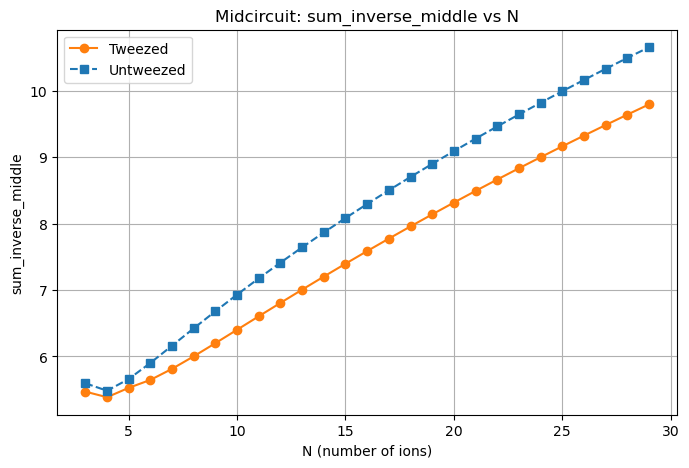

In [ ]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

dfs = []
many_N = []

for N in range(3, 30):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 30):
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
if Ns_u.size:
    plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
plt.xlabel("N (number of ions)")
plt.ylabel("sum_inverse_middle")
plt.title("Midcircuit: sum_inverse_middle vs N")
plt.grid(True)
plt.legend()
plt.show()

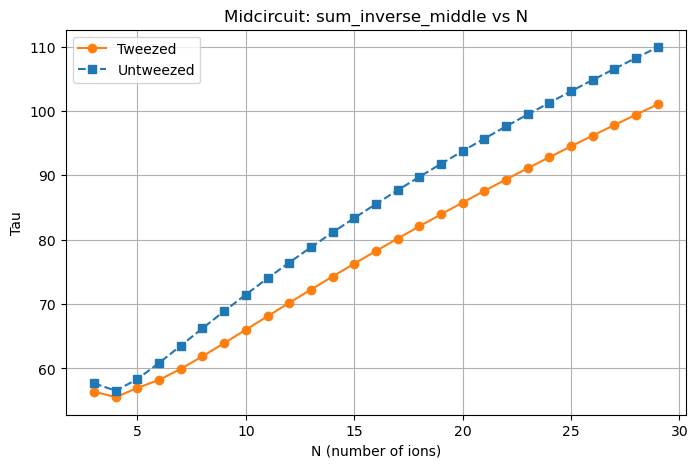

In [73]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

dfs = []
many_N = []

for N in range(3, 30):
    test_loop = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 30):
    test_loop = midcircuit_modes_untweezed_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
if Ns_u.size:
    plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
plt.xlabel("N (number of ions)")
plt.ylabel("Tau")
plt.title("Midcircuit: sum_inverse_middle vs N")
plt.grid(True)
plt.legend()
plt.show()

In [74]:
many_N

[(3,
     Tweezed Ion  Coolant Ion                                                    Mode couplings                                       inverse_mode_couplings  sum_inverse_middle
  0          1.0            0  [0.05285882810861294, -0.06858435881037099, 0.04368580422859406]  [18.918315743686676, 14.580583931168645, 22.89073115759332]           56.389631),
 (4,
     Tweezed Ion  Coolant Ion                                                     Mode couplings                                        inverse_mode_couplings  sum_inverse_middle
  0          1.0            0    [0.048305269683346405, -0.0616606089377412, 0.0537511333240099]  [20.701675128930237, 16.217809347450675, 18.604258890171412]           55.523743
  1          2.0            3  [0.048305269683354905, 0.06166060893778183, 0.053751133323981556]   [20.701675128926592, 16.217809347439992, 18.60425889018122]           55.523743),
 (5,
     Tweezed Ion  Coolant Ion                                                      Mode co

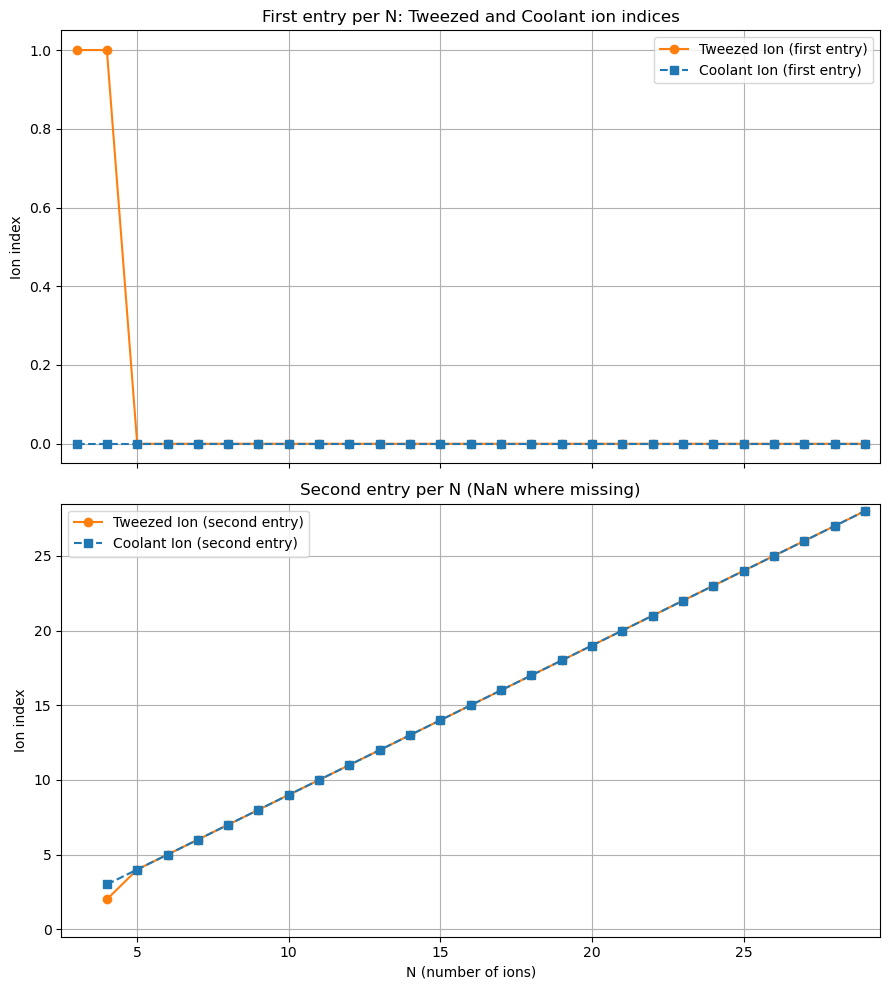

In [75]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(9,10), sharex=True)

axes[0].plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes[0].plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes[0].set_ylabel('Ion index')
axes[0].set_title('First entry per N: Tweezed and Coolant ion indices')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(Ns, second_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (second entry)')
axes[1].plot(Ns, second_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (second entry)')
axes[1].set_xlabel('N (number of ions)')
axes[1].set_ylabel('Ion index')
axes[1].set_title('Second entry per N (NaN where missing)')
axes[1].grid(True)
axes[1].legend()

plt.xlim(min(Ns)-0.5, max(Ns)+0.5)
valid_vals = [v for v in (first_t + first_c + second_t + second_c) if not np.isnan(v)]
if valid_vals:
    plt.ylim(-0.5, max(valid_vals) + 0.5)

plt.tight_layout()
plt.show()


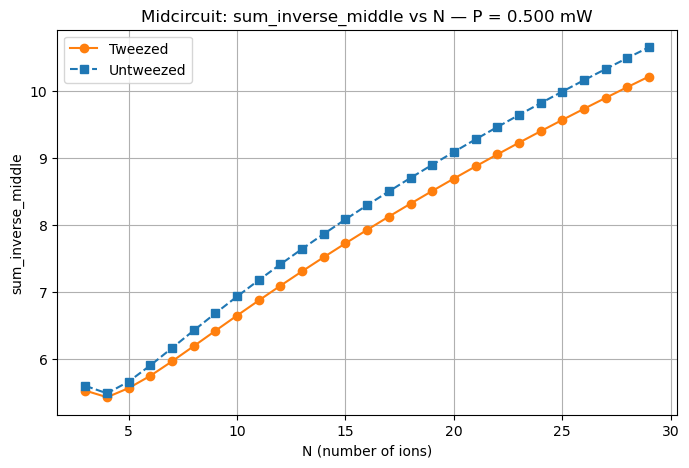

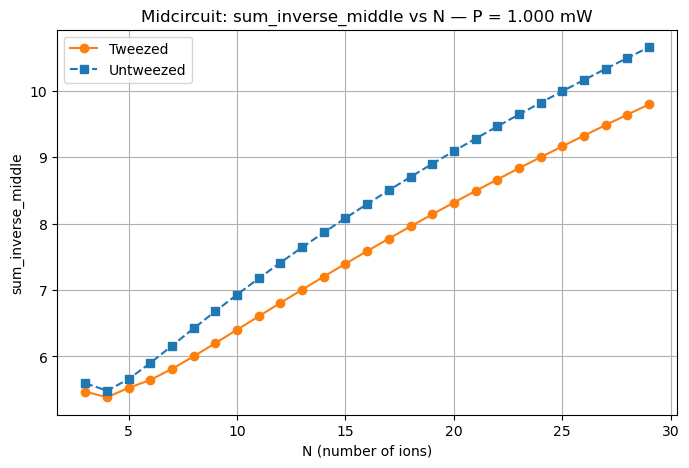

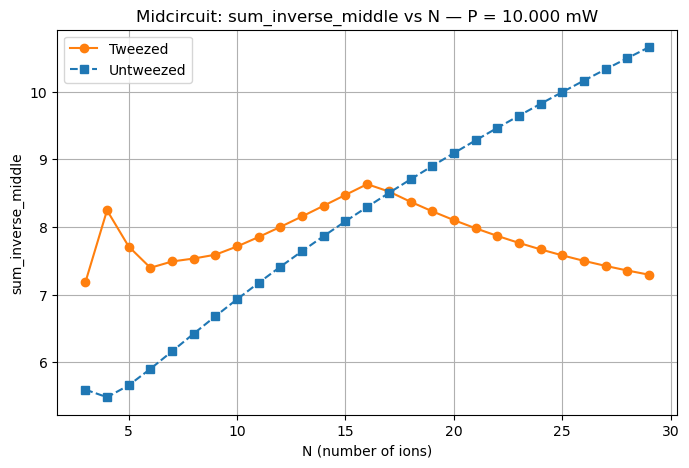

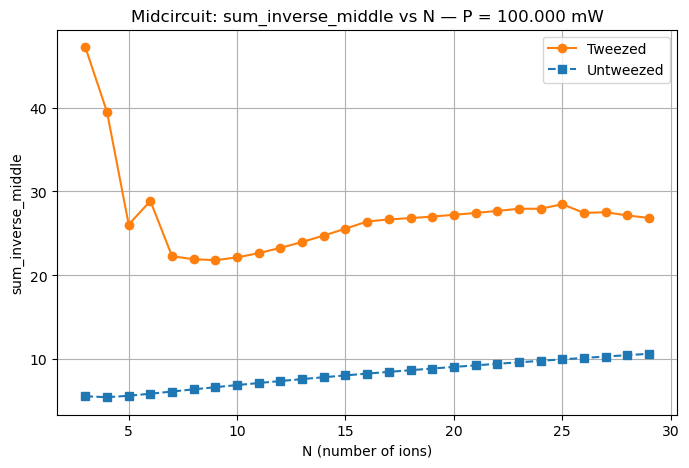

In [76]:
# ...existing code...
# loop over powers and plot per-power figure
import numpy as np
import matplotlib.pyplot as plt

# use the requested power list
power_values = [500e-6, 1e-3, 10e-3, 100e-3]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

for p in power_values:
    P_current = [p]    # functions expect a list-like P
    dfs = []
    dfs_untweezed = []
    many_N = []
    many_N_untweezed = []

    for N in range(3, 30):
        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, P_current, w0
        )
        many_N.append((N, test_loop))
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, P_current, w0
        )
        many_N_untweezed.append((N, test_loop_u))
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

    combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
    combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()


    Ns_t, vals_t = first_sum_by_N(combined_df)
    Ns_u, vals_u = first_sum_by_N(combined_untweezed)

    plt.figure(figsize=(8,5))
    if Ns_t.size:
        plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
    if Ns_u.size:
        plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
    plt.xlabel("N (number of ions)")
    plt.ylabel("sum_inverse_middle")
    # show power in mW instead of W
    plt.title(f"Midcircuit: sum_inverse_middle vs N — P = {p*1e3:.3f} mW")
    plt.grid(True)
    plt.legend()
    plt.show()
# ...existing code...

for N=10,N=20,N=30, what is the ratio of tweezed and untweezed as a function of power


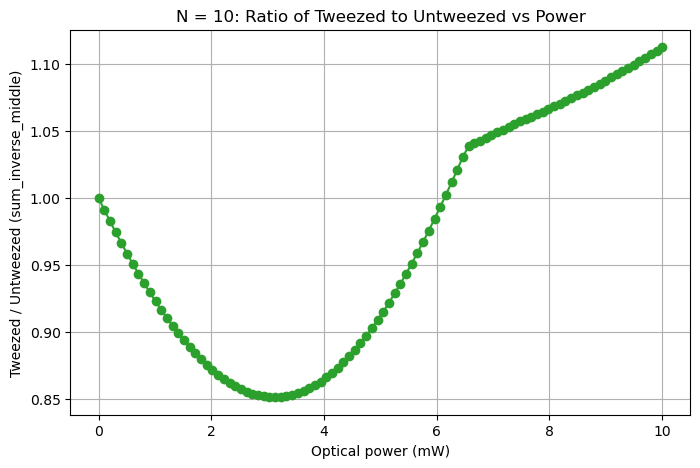

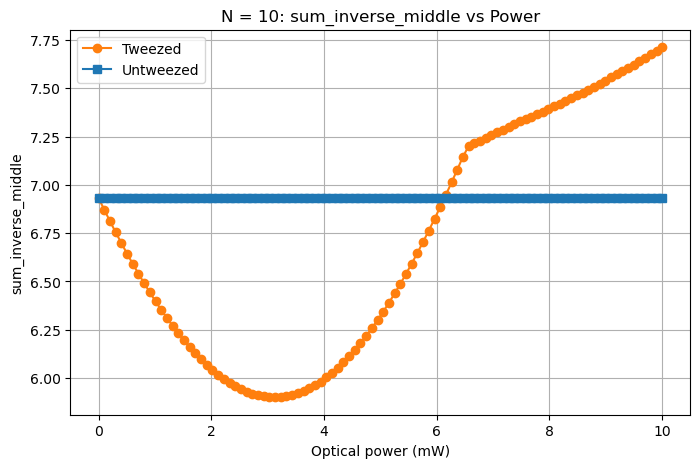

In [77]:
# ...existing code...
# fix N=10, sweep power and plot tweezed/untweezed ratio vs power
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6,10e-3,100)
N_fixed = 10

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = []
ratio_vals = []
t_vals = []
u_vals = []

for p in power_values:
    P_current = [p]
    dfs = []
    dfs_untweezed = []

    # only evaluate for fixed N
    test_loop = midcircuit_modes(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_fixed, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N_fixed)
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs.append(df)

    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_fixed, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N_fixed)
        try:
            dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs_untweezed.append(dfu)

    combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
    combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

    _, vals_t = first_sum_by_N(combined_df)
    _, vals_u = first_sum_by_N(combined_untweezed)

    # pick first (only) entry if present
    val_t = vals_t[0] if vals_t.size else np.nan
    val_u = vals_u[0] if vals_u.size else np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.nan if np.isnan(val_t) and np.isnan(val_u) else (np.nan if val_u == 0 else (val_t / val_u))

    powers_mW.append(p * 1e3)
    ratio_vals.append(ratio)
    t_vals.append(val_t)
    u_vals.append(val_u)

# plot ratio vs power (x in mW)
plt.figure(figsize=(8,5))
plt.plot(powers_mW, ratio_vals, marker='o', linestyle='-', color='C2')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title(f"N = {N_fixed}: Ratio of Tweezed to Untweezed vs Power")
plt.grid(True)
plt.show()

# optional: also show raw values
plt.figure(figsize=(8,5))
plt.plot(powers_mW, t_vals, marker='o', label='Tweezed', color='C1')
plt.plot(powers_mW, u_vals, marker='s', label='Untweezed', color='C0')
plt.xlabel("Optical power (mW)")
plt.ylabel("sum_inverse_middle")
plt.title(f"N = {N_fixed}: sum_inverse_middle vs Power")
plt.legend()
plt.grid(True)
plt.show()
# ...existing code...

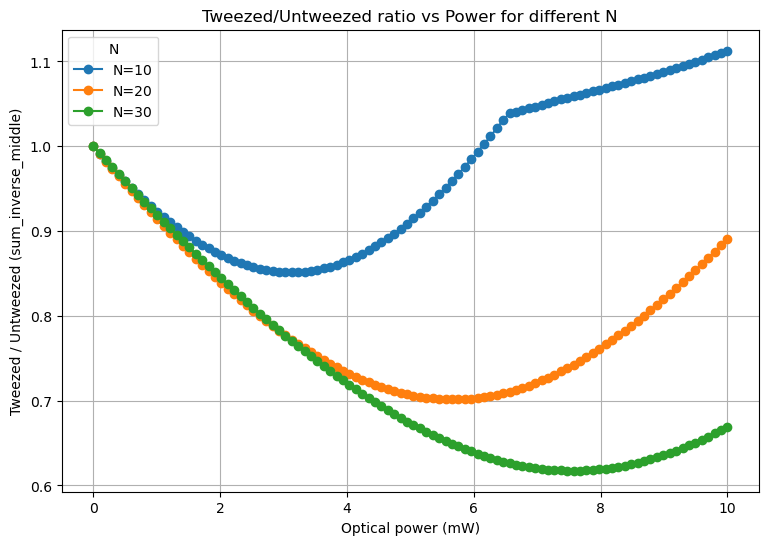

In [78]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


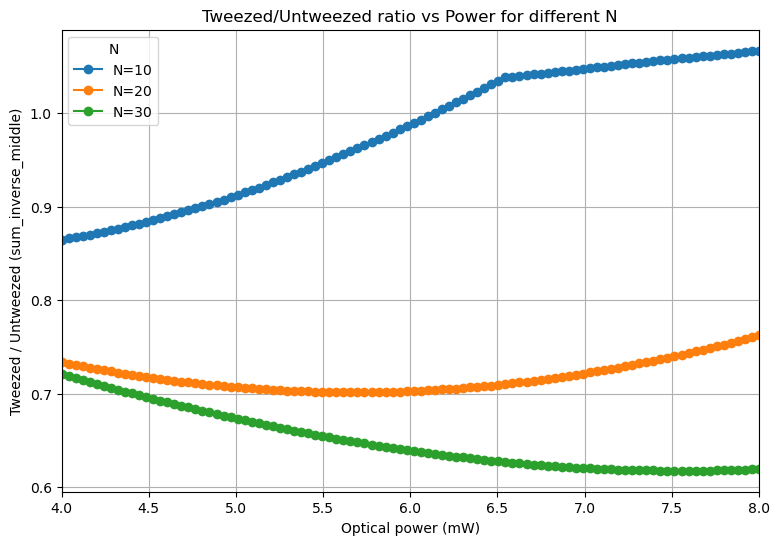

In [79]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values_zoomed_in = np.linspace(4e-3, 8e-3, 100)
Ns_to_plot = [10, 20, 30]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values_zoomed_in * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values_zoomed_in:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.xlim(min(powers_mW), max(powers_mW))
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


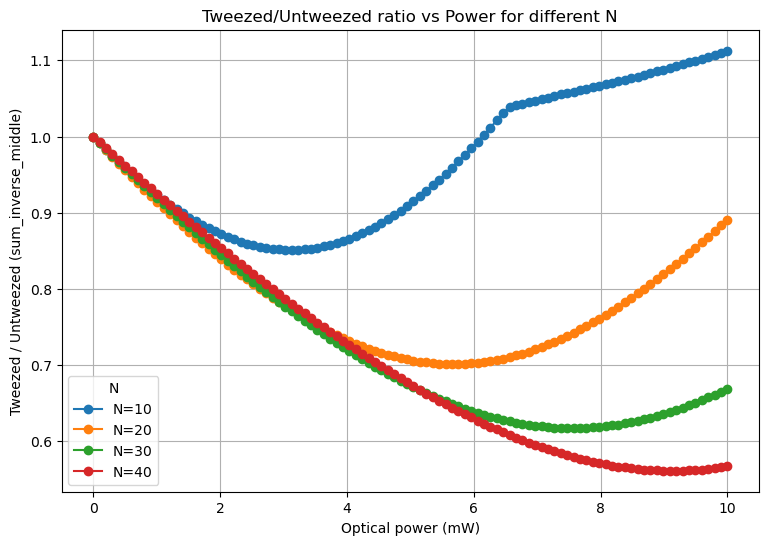

In [80]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


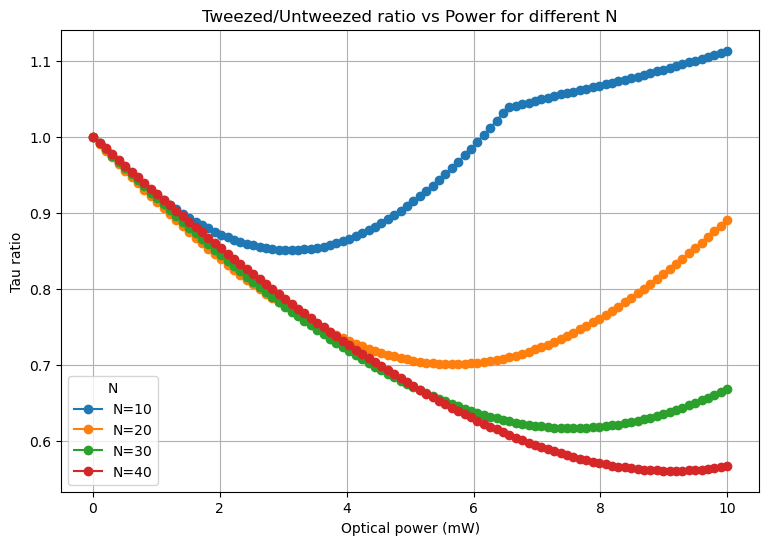

In [82]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)




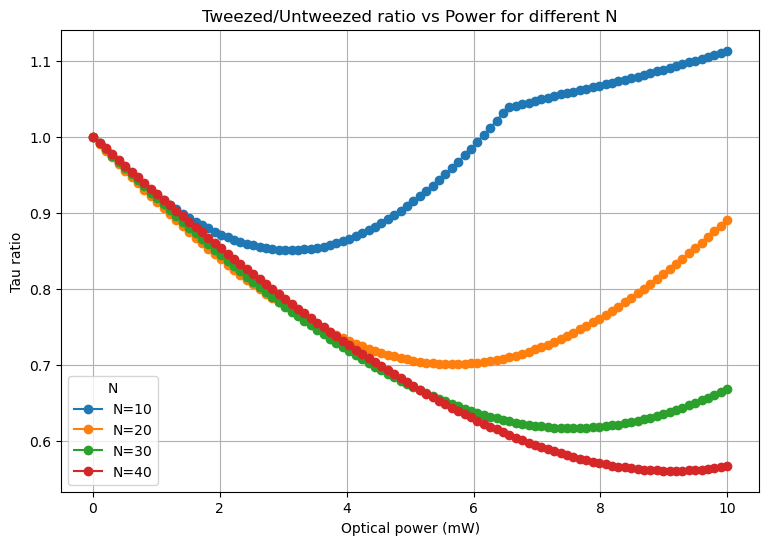

In [83]:
# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tau ratio")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()